# Behavioral Perspective
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

Behavioral segmentation, analyzing purchasing habits and travel behaviors

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#1st-bullet)<br>

[**Data Preposessing**](#2nd-bullet)<br>

    
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings

from sklearn.preprocessing import RobustScaler

from sklearn.metrics import silhouette_score, silhouette_samples # new library
from sklearn.cluster import KMeans # new library
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_context("notebook")
sns.set_style("ticks")

In [2]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()



In [3]:
Behavioral_columns = df_AIAI_Master.columns.to_list()[-60:]

df_AIAI_Behavioral = df_AIAI_Master[Behavioral_columns].copy()
df_AIAI_Behavioral.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610
549612,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500
429460,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.0000,6.1044,0.0000,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556
608370,73.0,81.0,42.0,143467.0,159407.0,83156.0,30.136986,30.864198,26.190476,82.0413,91.12,49.48,11.0,21.0,31.0,13.0,24.0,37.0,0.0,0.0,19.0,22.0,2.0,16.0,49255.0,35206.0,65665.0,37464.0,38224.0,45139.0,0.0,0.0,9285.0,53130.0,29241.0,23421.0,72.727273,52.380952,41.935484,0.000000,16.666667,0.000000,0.0,0.000000,10.526316,59.090909,0.000000,43.750000,-13.7374,-31.4985,65.6521,37.4562,38.2229,45.1288,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270
530508,39.0,43.0,89.0,126360.0,140400.0,99853.0,48.717949,48.837209,25.842697,126.3600,140.37,99.81,0.0,22.0,4.0,0.0,24.0,15.0,21.0,38.0,8.0,0.0,24.0,15.0,0.0,19731.0,5566.0,0.0,47106.0,54063.0,55404.0,73431.0,68327.0,0.0,40863.0,2122.0,0.000000,40.909091,100.000000,0.000000,25.000000,60.000000,0.0,34.210

# By year

In [5]:
df_AIAI_Behavioral_year = df_AIAI_Behavioral[df_AIAI_Behavioral.columns.to_list()[:12]].copy()
df_AIAI_Behavioral_year.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
Loyalty#,,,,,,,,,,,,
480934,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72
549612,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10
429460,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58
608370,73.0,81.0,42.0,143467.0,159407.0,83156.0,30.136986,30.864198,26.190476,82.0413,91.12,49.48
530508,39.0,43.0,89.0,126360.0,140400.0,99853.0,48.717949,48.837209,25.842697,126.3600,140.37,99.81


In [76]:
df_AIAI_Behavioral_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Total_NumFlights_2019              15101 non-null  float64
 1   Total_NumFlights_2020              15101 non-null  float64
 2   Total_NumFlights_2021              15101 non-null  float64
 3   Total_DistanceKM_2019              15101 non-null  float64
 4   Total_DistanceKM_2020              15101 non-null  float64
 5   Total_DistanceKM_2021              15101 non-null  float64
 6   Perc_Flights_With_Companions_2019  15101 non-null  float64
 7   Perc_Flights_With_Companions_2020  15101 non-null  float64
 8   Perc_Flights_With_Companions_2021  15101 non-null  float64
 9   Dollar_Cost_Points_Remaining_2019  15101 non-null  float64
 10  Dollar_Cost_Points_Remaining_2020  15101 non-null  float64
 11  Dollar_Cost_Points_Remaining_2021  15101 non-null  fl

In [6]:
df_AIAI_Behavioral_year.isna().sum()

Total_NumFlights_2019                1471
Total_NumFlights_2020                1471
Total_NumFlights_2021                1471
Total_DistanceKM_2019                1471
Total_DistanceKM_2020                1471
Total_DistanceKM_2021                1471
Perc_Flights_With_Companions_2019    1471
Perc_Flights_With_Companions_2020    1471
Perc_Flights_With_Companions_2021    1471
Dollar_Cost_Points_Remaining_2019    1471
Dollar_Cost_Points_Remaining_2020    1471
Dollar_Cost_Points_Remaining_2021    1471
dtype: int64

In [7]:
(df_AIAI_Behavioral_year < 0).sum()

Total_NumFlights_2019                  0
Total_NumFlights_2020                  0
Total_NumFlights_2021                  0
Total_DistanceKM_2019                  0
Total_DistanceKM_2020                  0
Total_DistanceKM_2021                  0
Perc_Flights_With_Companions_2019      0
Perc_Flights_With_Companions_2020      0
Perc_Flights_With_Companions_2021      0
Dollar_Cost_Points_Remaining_2019    700
Dollar_Cost_Points_Remaining_2020    700
Dollar_Cost_Points_Remaining_2021    777
dtype: int64

# Outliers Vizualizations

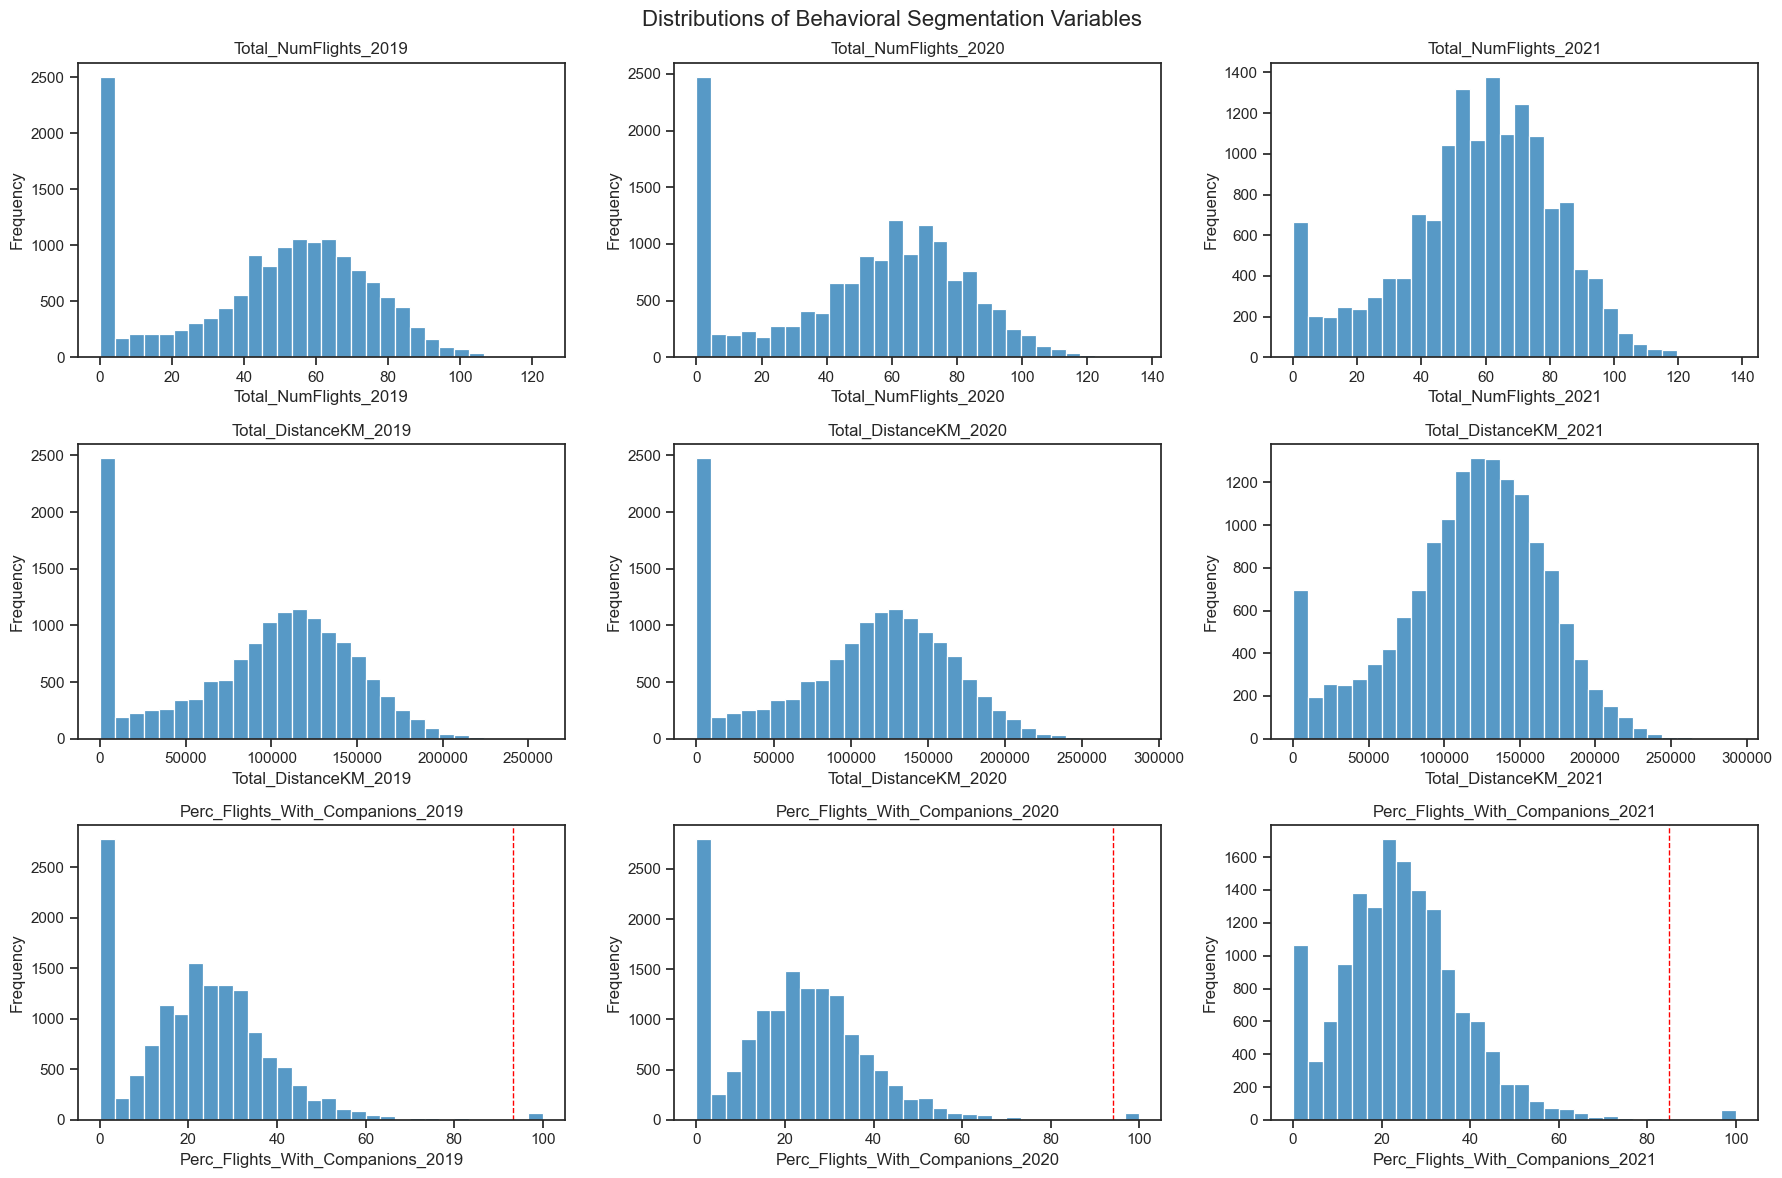

In [12]:
cols = [
    col for col in df_AIAI_Behavioral_year.columns
    if col != "Loyalty#"
]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    data = df_AIAI_Behavioral_year[col].dropna()

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Behavioral Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()

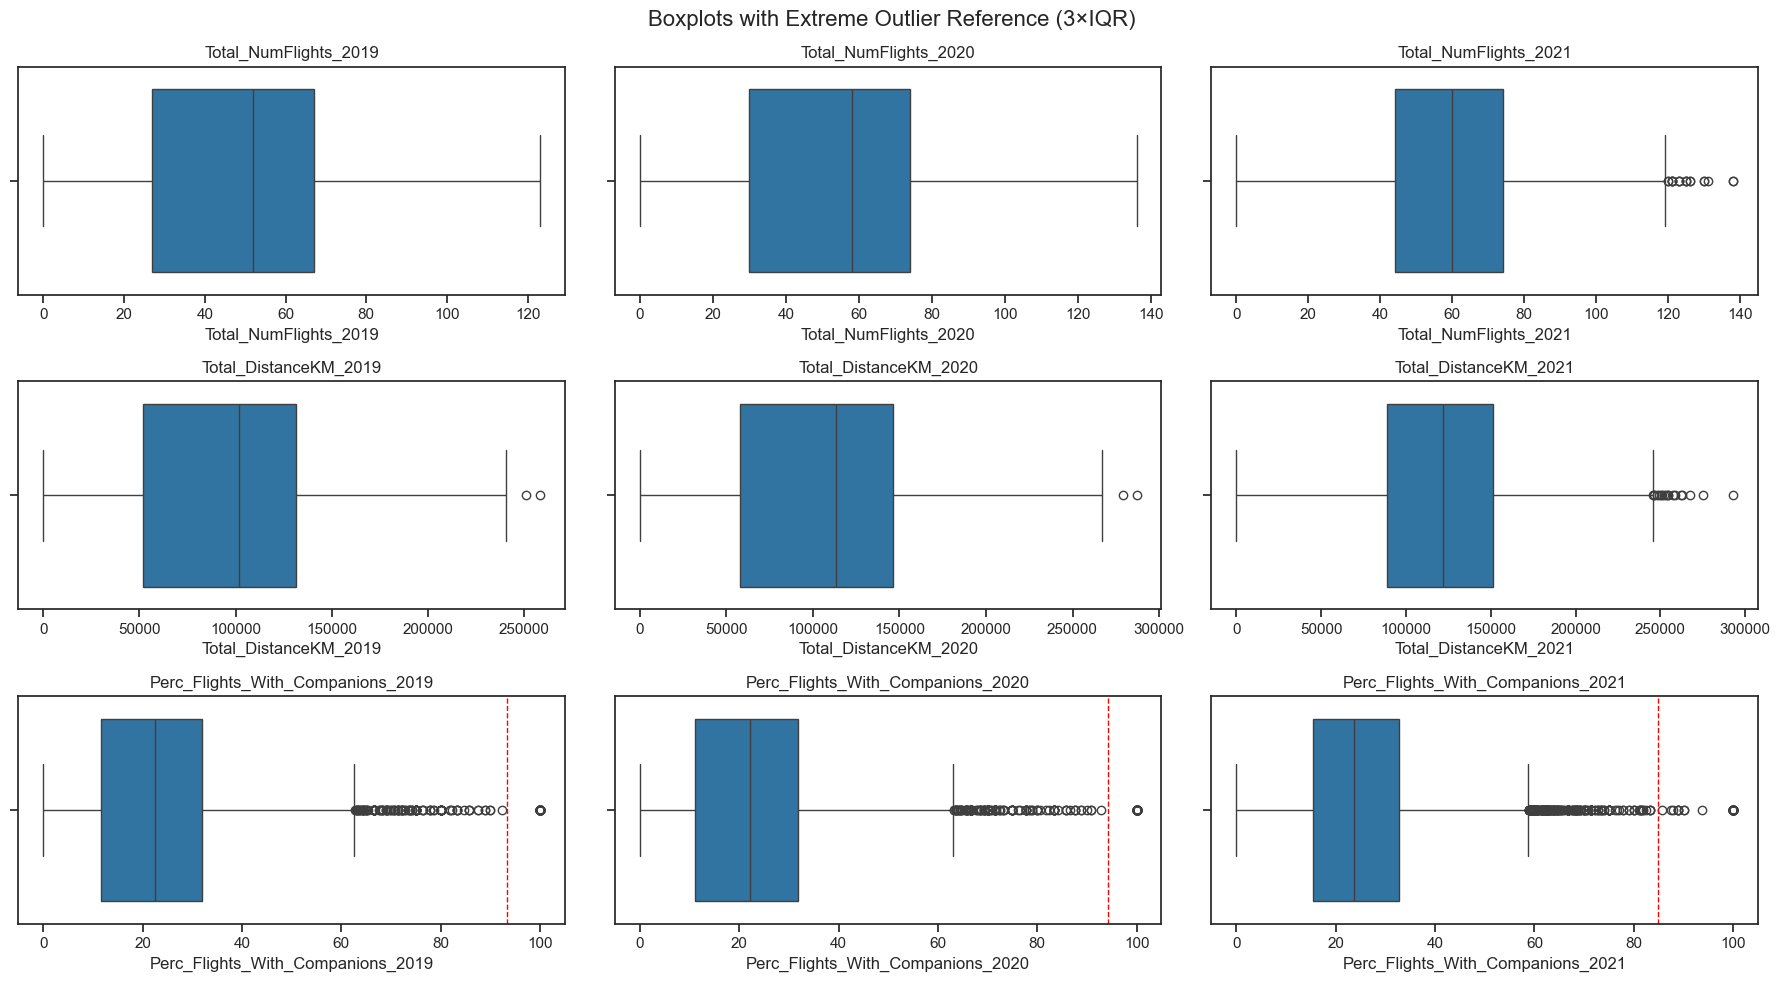

In [11]:
cols = [
    col for col in df_AIAI_Behavioral_year.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    
    data = df_AIAI_Behavioral_year[col].dropna()
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [88]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_AIAI_Behavioral_year)

In [89]:
kmclust = KMeans(n_clusters=8, init='random', n_init=10, random_state=1)
kmclust.fit(df_AIAI_Behavioral_year)

,n_clusters,8
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [90]:
kmclust.predict(df_AIAI_Behavioral_year)

array([6, 5, 7, ..., 4, 3, 2], dtype=int32)

In [91]:
pd.DataFrame(kmclust.transform(df_AIAI_Behavioral_year), columns=[f"ClusterDist_{i}" for i in range(8)]).head()

,ClusterDist_0,ClusterDist_1,ClusterDist_2,ClusterDist_3,ClusterDist_4,ClusterDist_5,ClusterDist_6,ClusterDist_7
0,205508.040762,127783.345321,135606.351054,270921.564218,134816.303859,161547.513639,82900.992010,225391.203262
1,179719.510576,98492.570420,40247.665337,201448.256961,65046.060789,31037.871651,50924.476072,110219.986668
2,168742.799351,135105.735138,95135.476324,139971.061730,159591.076641,95737.723809,150668.362521,23651.435139
3,207193.741317,134587.807192,72620.837910,212283.663672,70543.617460,12621.387112,92545.276997,103638.048917
4,179084.022018,104122.772939,42205.229375,192002.961846,76447.377183,21568.249464,70339.804842,93521.801585


In [92]:
kmclust = KMeans(n_clusters=8, init='k-means++', n_init=15, random_state=1)
kmclust.fit(df_AIAI_Behavioral_year)

,n_clusters,8
,init,'k-means++'
,n_init,15
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [93]:
kmclust.predict(df_AIAI_Behavioral_year)

array([5, 3, 1, ..., 0, 2, 6], dtype=int32)

In [94]:
range_clusters = range(1, 11)

inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df_AIAI_Behavioral_year)
    inertia.append(kmclust.inertia_) 

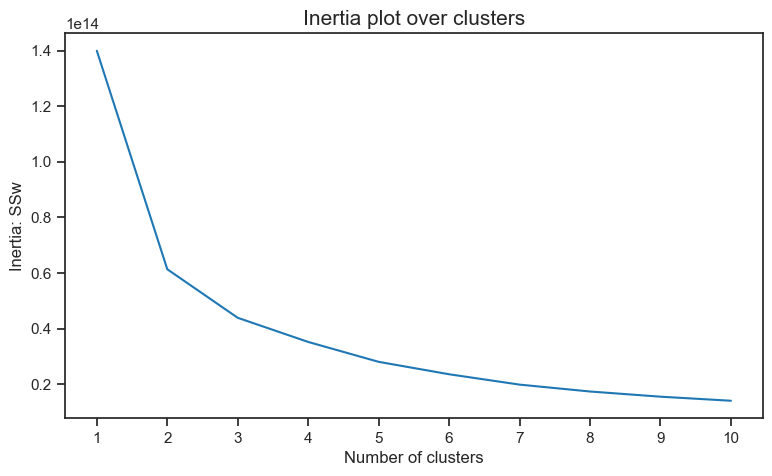

In [95]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [96]:
# final cluster solution
number_clusters = 2
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels = kmclust.fit_predict(df_AIAI_Behavioral_year)
km_labels

array([1, 1, 1, ..., 1, 0, 1], dtype=int32)

In [97]:
# Characterizing the final clusters
df_concat = pd.concat((df_AIAI_Behavioral_year, pd.Series(km_labels, name='labels', index=df_AIAI_Behavioral_year.index)), axis=1)
df_concat.groupby('labels').mean()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
labels,,,,,,,,,,,,
0,11.847392,13.149433,42.352381,18861.127211,20956.801134,83992.031519,13.297533,13.17161,23.739085,13.005436,14.444311,59.990256
1,59.548347,66.085923,63.246094,118677.496136,131863.848380,128950.862358,25.696998,25.48454,24.840443,83.290939,92.510446,90.773012


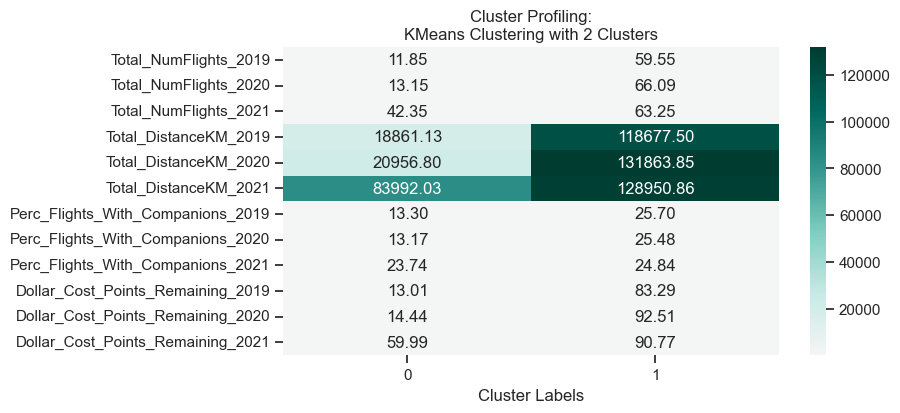

In [98]:
fig, ax = plt.subplots(figsize=(8,4))

km_profile = df_concat.groupby('labels').mean().T

sns.heatmap(km_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 2 Clusters")
plt.show()

In [100]:
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=5)
hc_labels = hclust.fit_predict(df_AIAI_Behavioral_year)
hc_labels

array([4, 1, 2, ..., 4, 0, 2])

In [ ]:
labels_series = pd.Series(hc_labels, 
                          name='labels', 
                          index=df_AIAI_Behavioral_year.index # WHY df.index ??
                          ) 

df_concat = pd.concat(
    [df_AIAI_Behavioral_year, labels_series],
    axis=1)


#df_concat

#df_concat[metric_features+['labels']].groupby('labels').mean()


In [111]:
# NUMPY solution:

# x_i       : X = df.values     : data
# x_bar     : X.mean(axis=0)    : centroid of data
# x_k       : X[hc_labels==k]   : points of cluster k
# x_bar_k   : X_k.mean(axis=0)  : centroid of cluster k
# n_k       : X_k.shape[0]

X = df_AIAI_Behavioral_year.values

# Computing SST
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)
print(f"SSt: {sst}")

# Computing SSW
ssw_iter = []                   # Outer summation
for i in np.unique(hc_labels):  # Loop for inner summation
    X_k = X[hc_labels == i]     # Data points belonging to cluster k
    inner_sum = np.sum(np.square(X_k - X_k.mean(axis=0)), axis=0)
    ssw_iter.append(inner_sum)  
ssw_per_feature = np.sum(ssw_iter, axis=0)  # Outer summation
ssw = np.sum(ssw_per_feature, axis=0)
print(f"SSw: {ssw}")

# Computing SSB
ssb_iter = []
for i in np.unique(hc_labels):  # Loop for summation
    X_k = X[hc_labels == i]     # Data points belonging to cluster k
    ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))

ssb_per_feature = np.sum(ssb_iter, axis=0)
ssb = np.sum(ssb_per_feature, axis=0)
print(f"SSb: {ssb}")

# Verifying the formula
np.round(sst) == np.round((ssw + ssb))

SSt: 139969043446939.03
SSw: 33317528161301.94
SSb: 106651515285637.17


np.True_

In [118]:
def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.

    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.

    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.

    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    
    return ss 


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns
    float: The between-group sum of squares of the DataFrame.
    """
    
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))) )

    ssb = np.sum(ssb_i)
    

    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.

    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats+[label_col]

    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats), 
        include_groups=False
        )

    return df_k.sum()

In [119]:
def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.

    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """

    df_sst_ = get_ss(df, feats)                 # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)     # get ss within
    df_ssb_ = df_sst_ - df_ssw_                 # get ss between

    # r2 = ssb/sst 
    return (df_ssb_/df_sst_)

In [113]:
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    """This function computes the R2 for a set of cluster solutions given by the application of a hierarchical method.
    The R2 is a measure of the homogenity of a cluster solution. It is based on SSt = SSw + SSb and R2 = SSb/SSt. 
    
    Parameters:
    df (DataFrame): Dataset to apply clustering
    link_method (str): either "ward", "complete", "average", "single"
    max_nclus (int): maximum number of clusters to compare the methods
    min_nclus (int): minimum number of clusters to compare the methods. Defaults to 1.
    dist (str): distance to use to compute the clustering solution. Must be a valid distance. Defaults to "euclidean".
    
    Returns:
    ndarray: R2 values for the range of cluster solutions
    """
    
    r2 = []  # where we will store the R2 metrics for each cluster solution
    feats = df.columns.tolist()
    
    for i in range(min_nclus, max_nclus+1):  # iterate over desired ncluster range
        
        # CODE HERE ####################################
        cluster = AgglomerativeClustering(linkage=link_method, metric=dist, n_clusters=i)
        
        #get cluster labels
        # CODE HERE ####################################
        hclabels = cluster.fit_predict(df[feats])
        
        # concat df with labels
        df_concat = pd.concat([df, pd.Series(hclabels, name='labels', index=df.index)], axis=1)  
        
        
        # append the R2 of the given cluster solution
        r2.append(get_rsq(df_concat, feats, 'labels'))
        
    return np.array(r2)